In [1]:
from langgraph.graph import StateGraph
from typing import Dict, Any, TypedDict
from IPython.display import display, Image

class loginState(TypedDict):
    password: str
    attempts: int

def get_password(state):
    state['password'] = input('Enter the login password: ')
    state['attempts'] = state.get("attempts", 0) + 1
    return state

def checklogic(state):
    actual_pass = '12345*Niv'
    given_pass = state['password']
    
    if given_pass == actual_pass:
        return 'correct'
    elif state['attempts'] >= 3:
        print('You have reached 3 attempts, locked wil be blocked. Please try after sometime')
        return 'locked'
    else:
        print('The entered password is not correct. Please try again')
        return 'incorrect'

def login(state):
    return state

def locked(state):
    return state

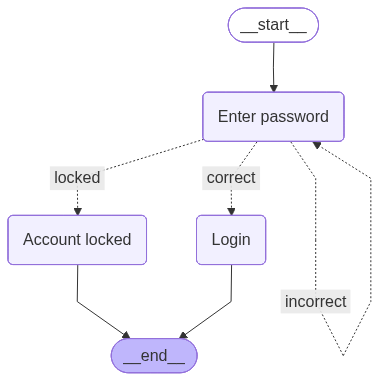

In [2]:
builder = StateGraph(loginState)
builder.add_node('Enter password',get_password)
builder.add_node('Login',login)
builder.add_node('Account locked',locked)

builder.set_entry_point('Enter password')

builder.add_conditional_edges('Enter password',checklogic,{
    'correct':'Login',
    'incorrect':'Enter password',
    'locked':'Account locked'
})

builder.set_finish_point('Login')
builder.set_finish_point('Account locked')

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization failed. Ensure Mermaid & pygraphviz dependencies are installed.")
    print(f"Error: {e}")

In [3]:
result = graph.invoke({})
print(result)

Enter the login password:  12345%


The entered password is not correct. Please try again


Enter the login password:  345579*


The entered password is not correct. Please try again


Enter the login password:  45097&


You have reached 3 attempts, locked wil be blocked. Please try after sometime
{'password': '45097&', 'attempts': 3}


In [4]:
result = graph.invoke({})
print(result)

Enter the login password:  789047


The entered password is not correct. Please try again


Enter the login password:  12345*Niv


{'password': '12345*Niv', 'attempts': 2}
